# BSAN 360 - 001 - Project
# Youssef Bastawy

In [27]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
import matplotlib.ticker as ticker

In [2]:
df = pd.read_csv("database_24_25.csv")

significant_minutes_threshold = 10
df_significant_minutes = df[df['MP'] > significant_minutes_threshold]

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
print("Minutes Played (MP) statistics:")
print(df['MP'].describe())

if df['MP'].dtype == 'object':

    try:
        df['MP'] = df['MP'].apply(lambda x: float(x.split(':')[0]) + float(x.split(':')[1])/60 if isinstance(x, str) and ':' in x else x)
    except:
        pass

    df['MP'] = pd.to_numeric(df['MP'], errors='coerce')

min_minutes = 30

df_significant = df[df['MP'] >= min_minutes]

print(f"Original dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"After filtering for players with {min_minutes}+ minutes: {df_significant.shape[0]} rows, {df_significant.shape[1]} columns")
print(f"Removed {df.shape[0] - df_significant.shape[0]} rows with less than {min_minutes} minutes played")

numerical_columns = df_significant.select_dtypes(include=['float64', 'int64']).columns
numeric_df = df_significant[numerical_columns]

correlation_matrix = numeric_df.corr()

high_correlation = correlation_matrix[abs(correlation_matrix) > 0.8].stack().reset_index()
high_correlation.columns = ['col1', 'col2', 'correlation']
high_correlation = high_correlation[high_correlation['col1'] != high_correlation['col2']]

columns_to_remove = high_correlation['col2'].tolist()

df_final = df_significant.drop(columns=columns_to_remove)

print(f"Final DataFrame shape after removing highly correlated columns: {df_final.shape[0]} rows, {df_final.shape[1]} columns")

df = df_final.copy()
print("Updated original df variable with filtered data:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Minutes Played (MP) statistics:
count    16512.000000
mean        22.405259
std         10.896645
min          0.000000
25%         14.427500
50%         23.430000
75%         31.322500
max         50.480000
Name: MP, dtype: float64
Original dataset: 16512 rows, 25 columns
After filtering for players with 30+ minutes: 4892 rows, 25 columns
Removed 11620 rows with less than 30 minutes played
Final DataFrame shape after removing highly correlated columns: 4892 rows, 17 columns
Updated original df variable with filtered data:
Rows: 4892
Columns: 17


,Player,Tm,Opp,Res,MP,FG%,3P,3PA,3P%,FT%,ORB,AST,STL,BLK,TOV,PF,Data
0,Jayson Tatum,BOS,NYK,W,30.30,0.778,8,11,0.727,0.500,0,10,1,1,1,1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,0.478,1,3,0.333,0.867,3,4,1,3,1,1,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,0.778,4,6,0.667,0.000,2,4,1,0,0,2,2024-10-22
5,Rui Hachimura,LAL,MIN,W,35.08,0.500,1,4,0.250,0.750,3,1,2,1,0,2,2024-10-22
7,Rudy Gobert,MIN,LAL,L,35.33,0.625,0,0,0.000,0.750,3,2,0,1,1,4,2024-10-22


In [4]:
print("First 5 rows:")
display(df.head())

print("Last 5 rows:")
display(df.tail())

First 5 rows:


,Player,Tm,Opp,Res,MP,FG%,3P,3PA,3P%,FT%,ORB,AST,STL,BLK,TOV,PF,Data
0,Jayson Tatum,BOS,NYK,W,30.30,0.778,8,11,0.727,0.500,0,10,1,1,1,1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,0.478,1,3,0.333,0.867,3,4,1,3,1,1,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,0.778,4,6,0.667,0.000,2,4,1,0,0,2,2024-10-22
5,Rui Hachimura,LAL,MIN,W,35.08,0.500,1,4,0.250,0.750,3,1,2,1,0,2,2024-10-22
7,Rudy Gobert,MIN,LAL,L,35.33,0.625,0,0,0.000,0.750,3,2,0,1,1,4,2024-10-22


Last 5 rows:


,Player,Tm,Opp,Res,MP,FG%,3P,3PA,3P%,FT%,ORB,AST,STL,BLK,TOV,PF,Data
16450,Carlton Carrington,WAS,CLE,L,35.82,0.556,3,6,0.500,0.0,1,3,0,0,4,1,2025-02-07
16465,Taurean Prince,MIL,ATL,L,30.82,0.571,1,4,0.250,0.0,0,1,0,0,0,4,2025-02-07
16467,Tim Hardaway Jr.,DET,PHI,W,30.80,0.222,2,8,0.250,0.0,0,3,0,1,0,0,2025-02-07
16479,Tyler Herro,MIA,BRK,L,37.78,0.273,2,11,0.182,1.0,1,6,1,0,4,3,2025-02-07
16480,Nikola Jović,MIA,BRK,L,31.73,0.375,2,5,0.400,0.0,0,4,2,0,4,3,2025-02-07


In [5]:
print("Original Columns")
print(df.columns.tolist())

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "pct")
    .str.replace("/", "_per_", regex=False)
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

print("Cleaned Columns")
print(df.columns.tolist())

if "team" in df.columns:
    df = df.set_index("team")
    print("Index set to: team")
elif "team_name" in df.columns:
    df = df.set_index("team_name")
    print("Index set to: team_name")
else:
    print("No team index column found; default index kept.")

display(df.head())

Original Columns
['Player', 'Tm', 'Opp', 'Res', 'MP', 'FG%', '3P', '3PA', '3P%', 'FT%', 'ORB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'Data']
Cleaned Columns
['player', 'tm', 'opp', 'res', 'mp', 'fgpct', '3p', '3pa', '3ppct', 'ftpct', 'orb', 'ast', 'stl', 'blk', 'tov', 'pf', 'data']
No team index column found; default index kept.


,player,tm,opp,res,mp,fgpct,3p,3pa,3ppct,ftpct,orb,ast,stl,blk,tov,pf,data
0,Jayson Tatum,BOS,NYK,W,30.30,0.778,8,11,0.727,0.500,0,10,1,1,1,1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,0.478,1,3,0.333,0.867,3,4,1,3,1,1,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,0.778,4,6,0.667,0.000,2,4,1,0,0,2,2024-10-22
5,Rui Hachimura,LAL,MIN,W,35.08,0.500,1,4,0.250,0.750,3,1,2,1,0,2,2024-10-22
7,Rudy Gobert,MIN,LAL,L,35.33,0.625,0,0,0.000,0.750,3,2,0,1,1,4,2024-10-22


In [6]:
research_question = (
    "Which statistical categories (shooting efficiency, turnovers, rebounds, etc.) "
    "best predict winning games?"
)
print("Research Question:")
print(research_question)

if "res" in df.columns:
    df["target_win"] = (df["res"].astype(str).str.upper() == "W").astype(int)
elif "Res" in df.columns:
    df["target_win"] = (df["Res"].astype(str).str.upper() == "W").astype(int)
else:
    raise ValueError("Could not find result column (res/Res) to build win target.")

target = "target_win"
print("Selected target variable:", target)

candidate_predictors = [
    "fg_pct", "fg%", "fg",
    "3p_pct", "3p%", "3p", "3pa",
    "ft_pct", "ft%", "ft", "fta",
    "orb", "drb", "trb",
    "ast", "stl", "blk", "tov", "pf",
    "pts", "gmsc", "mp", "fga"
]

predictors = [c for c in candidate_predictors if c in df.columns]

print("Predictor columns found:")
print(predictors)

if len(predictors) < 3:
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    print("Few standard predictors found. Numeric columns available:")
    print(numeric_cols)

Research Question:
Which statistical categories (shooting efficiency, turnovers, rebounds, etc.) best predict winning games?
Selected target variable: target_win
Predictor columns found:
['3p', '3pa', 'orb', 'ast', 'stl', 'blk', 'tov', 'pf', 'mp']


In [7]:
# Target: win_pct (or wins)
# Predictors: shooting (fg_pct, efg_pct, ts_pct), turnovers (tov / tov_pct), rebounding (reb, oreb, dreb), plus control metrics (pace, off_rating, def_rating).

In [8]:
project_cols = predictors + [target]
nba = df[project_cols].copy()

print("Focused DataFrame shape (before cleaning):", nba.shape)
display(nba.head())

nba = nba.dropna(subset=[target])

for c in predictors:
    if nba[c].isna().any():
        nba[c] = nba[c].fillna(nba[c].median())

print("Focused DataFrame shape (after cleaning):", nba.shape)
print("Any missing values left?")
display(nba.isna().sum())

Focused DataFrame shape (before cleaning): (4892, 10)


,3p,3pa,orb,ast,stl,blk,tov,pf,mp,target_win
0,8,11,0,10,1,1,1,1,30.30,1
1,1,3,3,4,1,3,1,1,37.58,1
3,4,6,2,4,1,0,0,2,30.52,1
5,1,4,3,1,2,1,0,2,35.08,1
7,0,0,3,2,0,1,1,4,35.33,0


Focused DataFrame shape (after cleaning): (4892, 10)
Any missing values left?


3p            0
3pa           0
orb           0
ast           0
stl           0
blk           0
tov           0
pf            0
mp            0
target_win    0
dtype: int64

In [9]:
# Analysis 1: Correlation screen
corr = nba.corr(numeric_only=True)[target].sort_values(ascending=False)
print("Correlation with target:")
display(corr)

top_abs_corr = corr.drop(labels=[target], errors="ignore").abs().sort_values(ascending=False)
print("Top predictors by absolute correlation:")
display(top_abs_corr.head(10))

# Analysis 2: Multiple linear regression
X = nba[predictors]
y = nba[target]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

Correlation with target:


target_win    1.000000
ast           0.084789
blk           0.059775
3p            0.059075
stl           0.053413
mp            0.000770
orb           0.000607
3pa          -0.018616
tov          -0.047921
pf           -0.061306
Name: target_win, dtype: float64

Top predictors by absolute correlation:


ast    0.084789
pf     0.061306
blk    0.059775
3p     0.059075
stl    0.053413
tov    0.047921
3pa    0.018616
mp     0.000770
orb    0.000607
Name: target_win, dtype: float64

                            OLS Regression Results                            
Dep. Variable:             target_win   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     22.35
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.23e-37
Time:                        21:44:19   Log-Likelihood:                -3451.5
No. Observations:                4892   AIC:                             6923.
Df Residuals:                    4882   BIC:                             6988.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5331      0.075      7.070      0.0

In [10]:
# I use correlation to screen relationships and multiple linear regression to identify which categories most strongly predict team success while controlling for the others.

# Project 2

In [11]:
print("DATA CLEANING AND PREPARATION")

print("Initial dataset overview:")
print("Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("Column names:")
print(df.columns.tolist())

print("Data types:")
print(df.dtypes)

print("Missing values per column:")
print(df.isna().sum())

print("Basic statistics for numerical columns:")
print(df.describe())

DATA CLEANING AND PREPARATION
Initial dataset overview:
Rows: {df.shape[0]}, Columns: {df.shape[1]}
Column names:
['player', 'tm', 'opp', 'res', 'mp', 'fgpct', '3p', '3pa', '3ppct', 'ftpct', 'orb', 'ast', 'stl', 'blk', 'tov', 'pf', 'data', 'target_win']
Data types:
player         object
tm             object
opp            object
res            object
mp            float64
fgpct         float64
3p              int64
3pa             int64
3ppct         float64
ftpct         float64
orb             int64
ast             int64
stl             int64
blk             int64
tov             int64
pf              int64
data           object
target_win      int64
dtype: object
Missing values per column:
player        0
tm            0
opp           0
res           0
mp            0
fgpct         0
3p            0
3pa           0
3ppct         0
ftpct         0
orb           0
ast           0
stl           0
blk           0
tov           0
pf            0
data          0
target_win    0
dtype: in

In [12]:
print("HANDLING MISSING DATA")

missing_values = df.isna().sum()
columns_with_missing = missing_values[missing_values > 0].index.tolist()

print("Columns with missing values: {columns_with_missing}")

print("Justification for handling missing data:")
print("For our basketball analysis, we're focusing on key players with significant playing time.")
print("Players with missing statistics likely had minimal impact on the game.")
print("Therefore, we'll filter out players with less than 30 minutes of playing time.")

df.columns = df.columns.str.strip()

df['mp'] = pd.to_numeric(df['mp'], errors='coerce')

min_minutes = 30

df_filtered = df[df['mp'] >= min_minutes]

print("nOriginal dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print("After filtering for players with {min_minutes}+ minutes: {df_filtered.shape[0]} rows, {df_filtered.shape[1]} columns")
print("Removed {df.shape[0] - df_filtered.shape[0]} rows with less than {min_minutes} minutes played")

missing_after_filter = df_filtered.isna().sum()
columns_still_missing = missing_after_filter[missing_after_filter > 0].index.tolist()

print("Columns still with missing values after filtering: {columns_still_missing}")

if columns_still_missing:
    key_stats = ['PTS', 'FG%', 'TRB', 'AST']
    key_stats_present = [col for col in key_stats if col in df_filtered.columns]
    
    if key_stats_present:
        df_filtered = df_filtered.dropna(subset=key_stats_present)
        print(f"Dropped rows with missing values in key statistics: {key_stats_present}")
        print(f"Remaining dataset: {df_filtered.shape[0]} rows")

HANDLING MISSING DATA
Columns with missing values: {columns_with_missing}
Justification for handling missing data:
For our basketball analysis, we're focusing on key players with significant playing time.
Players with missing statistics likely had minimal impact on the game.
Therefore, we'll filter out players with less than 30 minutes of playing time.
nOriginal dataset: {df.shape[0]} rows, {df.shape[1]} columns
After filtering for players with {min_minutes}+ minutes: {df_filtered.shape[0]} rows, {df_filtered.shape[1]} columns
Removed {df.shape[0] - df_filtered.shape[0]} rows with less than {min_minutes} minutes played
Columns still with missing values after filtering: {columns_still_missing}


In [13]:
print("DATA TRANSFORMATIONS")

percentage_cols = [col for col in df_filtered.columns if '%' in col]
print(f"Percentage columns: {percentage_cols}")

for col in percentage_cols:
    if df_filtered[col].dtype == 'object':
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')
    
    if df_filtered[col].max() > 1:
        df_filtered[col] = df_filtered[col] / 100
        print(f"Converted {col} from percentage to decimal format")

print("Creating additional efficiency metrics:")

if all(col in df_filtered.columns for col in ['PTS', 'FGA']):
    df_filtered['PPS'] = df_filtered['PTS'] / df_filtered['FGA'].replace(0, np.nan)
    print("- Added Points Per Shot (PPS) metric")

if all(col in df_filtered.columns for col in ['AST', 'TOV']):
    df_filtered['AST/TOV'] = df_filtered['AST'] / df_filtered['TOV'].replace(0, np.nan)
    print("- Added Assist to Turnover ratio (AST/TOV)")

if all(col in df_filtered.columns for col in ['PTS', 'FGA', 'FTA']):
    df_filtered['TS%'] = df_filtered['PTS'] / (2 * (df_filtered['FGA'] + 0.44 * df_filtered['FTA']))
    print("- Added True Shooting Percentage (TS%)")

print("Identifying and removing highly correlated features:")

numerical_columns = df_filtered.select_dtypes(include=['float64', 'int64']).columns
numeric_df = df_filtered[numerical_columns]
correlation_matrix = numeric_df.corr()

high_correlation = correlation_matrix[abs(correlation_matrix) > 0.8].stack().reset_index()
high_correlation.columns = ['col1', 'col2', 'correlation']
high_correlation = high_correlation[high_correlation['col1'] != high_correlation['col2']]

print("Highly correlated feature pairs (correlation > 0.8):")
for _, row in high_correlation.iterrows():
    print(f"- {row['col1']} and {row['col2']}: {row['correlation']:.3f}")

columns_to_remove = high_correlation['col2'].tolist()
print(f"Removing {len(columns_to_remove)} highly correlated columns: {columns_to_remove}")

df_cleaned = df_filtered.drop(columns=columns_to_remove)

DATA TRANSFORMATIONS
Percentage columns: []
Creating additional efficiency metrics:
Identifying and removing highly correlated features:
Highly correlated feature pairs (correlation > 0.8):
Removing 0 highly correlated columns: []


In [14]:
print("FINAL CLEANED DATASET")

print(f"Final dataset dimensions: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns")
print("Remaining columns:")
print(df_cleaned.columns.tolist())

print("Missing values in final dataset:")
print(df_cleaned.isna().sum().sum(), "total missing values")

print("Sample of final cleaned dataset:")
print(df_cleaned.head())

df = df_cleaned.copy()

FINAL CLEANED DATASET
Final dataset dimensions: 4892 rows, 18 columns
Remaining columns:
['player', 'tm', 'opp', 'res', 'mp', 'fgpct', '3p', '3pa', '3ppct', 'ftpct', 'orb', 'ast', 'stl', 'blk', 'tov', 'pf', 'data', 'target_win']
Missing values in final dataset:
0 total missing values
Sample of final cleaned dataset:
          player   tm  opp res     mp  fgpct  3p  3pa  3ppct  ftpct  orb  ast  \
0   Jayson Tatum  BOS  NYK   W  30.30  0.778   8   11  0.727  0.500    0   10   
1  Anthony Davis  LAL  MIN   W  37.58  0.478   1    3  0.333  0.867    3    4   
3   Jrue Holiday  BOS  NYK   W  30.52  0.778   4    6  0.667  0.000    2    4   
5  Rui Hachimura  LAL  MIN   W  35.08  0.500   1    4  0.250  0.750    3    1   
7    Rudy Gobert  MIN  LAL   L  35.33  0.625   0    0  0.000  0.750    3    2   

   stl  blk  tov  pf        data  target_win  
0    1    1    1   1  2024-10-22           1  
1    1    3    1   1  2024-10-22           1  
3    1    0    0   2  2024-10-22           1  
5    2 

# Project 3

In [15]:
if 'df_cleaned' in globals():
    p3_df = df_cleaned.copy()
elif 'df' in globals():
    p3_df = df.copy()
else:
    raise NameError("No dataframe found from Project 2 (expected 'df_cleaned' or 'df').")

print("Project 3 starting dataframe shape:", p3_df.shape)


# 1) Processing Strings

# I will process string columns only if they exist in this dataset.
string_cols = p3_df.select_dtypes(include=['object', 'string']).columns.tolist()

if len(string_cols) == 0:
    print("Processing Strings not applied: this dataset does not currently have string columns to clean/process.")
else:
    for col in string_cols:
        p3_df[col] = p3_df[col].astype(str).str.strip()

   
    first_str_col = string_cols[0]
    p3_df[first_str_col + "_lower"] = p3_df[first_str_col].str.lower()
    p3_df[first_str_col + "_char_count"] = p3_df[first_str_col].str.len()

    print("Processing Strings completed on column(s):", string_cols)
    print(p3_df[[first_str_col, first_str_col + "_lower", first_str_col + "_char_count"]].head())


Project 3 starting dataframe shape: (4892, 18)
Processing Strings completed on column(s): ['player', 'tm', 'opp', 'res', 'data']
          player   player_lower  player_char_count
0   Jayson Tatum   jayson tatum                 12
1  Anthony Davis  anthony davis                 13
3   Jrue Holiday   jrue holiday                 12
5  Rui Hachimura  rui hachimura                 13
7    Rudy Gobert    rudy gobert                 11


In [16]:
# 2) Combining and Merging Datasets

# This project uses one main file, so a real merge/combine step is not necessary.
print("Combining/Merging not required: this project uses one main dataset file, so no second dataset is available to merge.")

Combining/Merging not required: this project uses one main dataset file, so no second dataset is available to merge.


In [17]:
# 3) Data Wrangling: Reshaping and Pivoting

numeric_cols = p3_df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) < 2:
    print("Reshaping/Pivoting not fully applied: need at least 2 numeric columns for a clear melt/pivot example.")
else:
    preferred_id_cols = ['Player', 'player', 'Name', 'name', 'Team', 'team', 'Pos', 'position']
    id_col = None
    for c in preferred_id_cols:
        if c in p3_df.columns:
            id_col = c
            break

    if id_col is None:
        p3_df = p3_df.reset_index().rename(columns={'index': 'row_id'})
        id_col = 'row_id'

    value_cols = numeric_cols[:3]

    long_df = p3_df[[id_col] + value_cols].melt(
        id_vars=id_col,
        value_vars=value_cols,
        var_name='metric',
        value_name='value'
    )
    print("Melted (long) dataframe sample:")
    print(long_df.head())

    pivot_df = long_df.pivot_table(
        index='metric',
        values='value',
        aggfunc=['mean', 'median', 'count']
    )
    print("Pivot table summary:")
    print(pivot_df)

Melted (long) dataframe sample:
          player metric  value
0   Jayson Tatum     mp  30.30
1  Anthony Davis     mp  37.58
2   Jrue Holiday     mp  30.52
3  Rui Hachimura     mp  35.08
4    Rudy Gobert     mp  35.33
Pivot table summary:
             mean  median count
            value   value value
metric                         
3p       2.165372   2.000  4892
fgpct    0.482701   0.474  4892
mp      34.864025  34.475  4892


# Project 4

In [18]:
def _pick_any_df():
    dfs = [(k, v) for k, v in globals().items() if isinstance(v, pd.DataFrame)]
    if not dfs:
        raise NameError("No pandas DataFrame found in memory. Run the data loading/cleaning cells first.")

    name, df_ = max(dfs, key=lambda kv: kv[1].shape[0] * kv[1].shape[1])
    return df_.copy(), name

viz_df, viz_df_name = _pick_any_df()
print(f"Using dataframe for plots: {viz_df_name} with shape {viz_df.shape}")

TARGET_COL = None

def _infer_target(df):

    hints = ["win", "wins", "result", "outcome", "target", "label", "won", "w_l", "wl", "status"]
    cols = list(df.columns)

    ranked = sorted(cols, key=lambda c: (0 if any(h in str(c).lower() for h in hints) else 1, str(c).lower()))
    for c in ranked:
        s = df[c].dropna()
        if s.empty:
            continue
        nunique = s.nunique()
        if nunique == 2:
            return c
    return None

if TARGET_COL is None:
    TARGET_COL = _infer_target(viz_df)

if TARGET_COL is None:
    raise NameError("Could not auto-detect a binary target column. Set TARGET_COL manually (e.g., TARGET_COL='win').")

print("Target column:", TARGET_COL)
print(viz_df[TARGET_COL].value_counts(dropna=False))

target_series = viz_df[TARGET_COL]
if target_series.dtype.name == "category":
    target_series = target_series.astype(str)

vals = [v for v in target_series.dropna().unique()]
if len(vals) != 2:
    raise ValueError(f"Target column {TARGET_COL} does not have exactly 2 unique values after dropping NAs.")

map01 = {vals[0]: 0, vals[1]: 1}
y01 = target_series.map(map01)

if y01.isna().mean() > 0.25:
    y01 = pd.Series(pd.factorize(target_series)[0], index=viz_df.index)
    y01 = (y01 == y01.max()).astype(int)



Using dataframe for plots: df_significant_minutes with shape (13790, 25)
Target column: Res
Res
L    6934
W    6856
Name: count, dtype: int64


In [19]:
num_cols = viz_df.select_dtypes(include=np.number).columns.tolist()
if len(num_cols) == 0:
    raise ValueError("No numeric columns found to plot.")

tmp = viz_df[num_cols].copy()
tmp["_target01"] = y01
corr = tmp.corr(numeric_only=True)["_target01"].drop("_target01").abs().sort_values(ascending=False)

id_like = {"id", "index", "playerid", "matchid", "gameid"}
top_features = [c for c in corr.index if str(c).lower() not in id_like][:10]
if len(top_features) == 0:
    top_features = corr.index.tolist()[:10]

best_feature = top_features[0]
print("Top features by |corr with outcome|:")
print(corr.loc[top_features].head(10))

corr_pred = viz_df[num_cols].corr(numeric_only=True).abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))
pair = upper.stack().sort_values(ascending=False)
best_pair = None
if not pair.empty:
    best_pair = pair.index[0]  # (colA, colB)
    best_pair_r = pair.iloc[0]
    print("Most correlated numeric pair:", best_pair, " |r|=", round(float(best_pair_r), 3))
else:
    print("Not enough numeric columns to compute predictor-pair correlation.")


Top features by |corr with outcome|:
GmSc    0.159147
FG%     0.123686
3P%     0.094625
PTS     0.091020
FG      0.088346
3P      0.083651
DRB     0.078682
AST     0.077763
TRB     0.064369
STL     0.060529
Name: _target01, dtype: float64
Most correlated numeric pair: ('FG', 'PTS')  |r|= 0.961


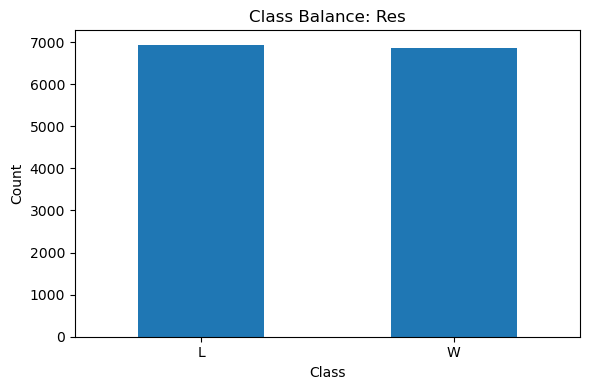

In [20]:
plt.figure(figsize=(6,4))
viz_df[TARGET_COL].value_counts(dropna=False).plot(kind="bar")
plt.title(f"Class Balance: {TARGET_COL}")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

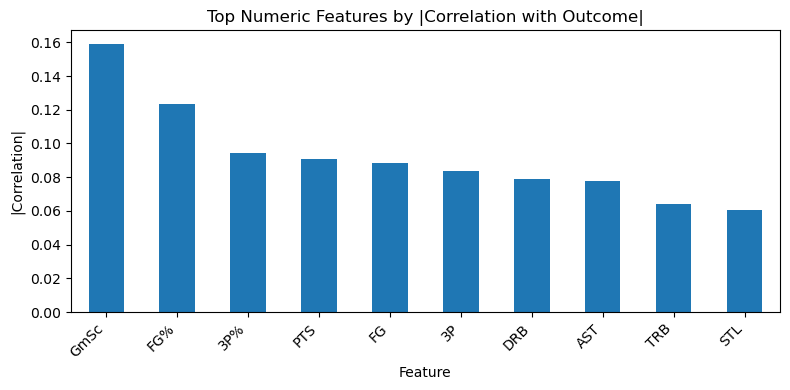

Interpretation: Higher bars suggest features more likely to help predict the outcome. Very low bars may indicate weak predictors.


In [21]:
plt.figure(figsize=(8,4))
corr.loc[top_features[:10]].sort_values(ascending=False).plot(kind="bar")
plt.title("Top Numeric Features by |Correlation with Outcome|")
plt.xlabel("Feature")
plt.ylabel("|Correlation|")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Interpretation: Higher bars suggest features more likely to help predict the outcome. Very low bars may indicate weak predictors.")

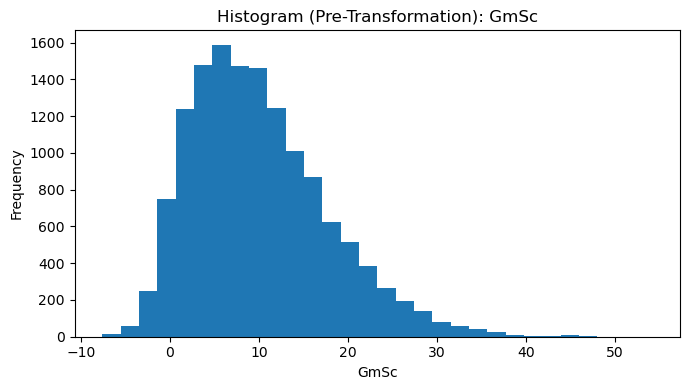

In [22]:
plt.figure(figsize=(7,4))
plt.hist(viz_df[best_feature].dropna(), bins=30)
plt.title(f"Histogram (Pre-Transformation): {best_feature}")
plt.xlabel(best_feature)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

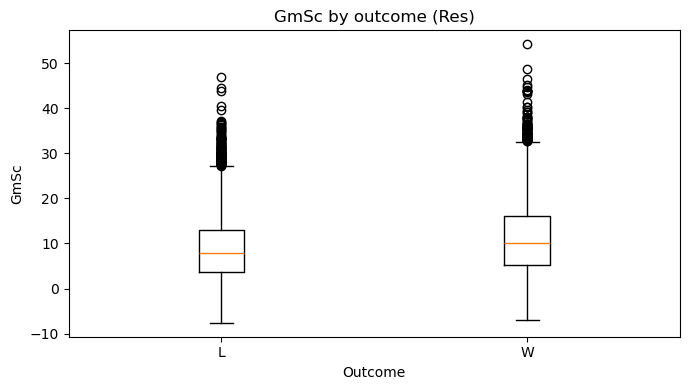

Interpretation: If medians/IQR differ clearly across classes, the feature is useful. If they overlap heavily, it may add little value.


In [23]:
labels = list(viz_df[TARGET_COL].dropna().unique())
labels = sorted(labels, key=lambda x: str(x))

data = [viz_df.loc[viz_df[TARGET_COL] == lab, best_feature].dropna() for lab in labels]

plt.figure(figsize=(7, 4))
plt.boxplot(data, tick_labels=[str(l) for l in labels])
plt.title(f"{best_feature} by outcome ({TARGET_COL})")
plt.xlabel("Outcome")
plt.ylabel(best_feature)
plt.tight_layout()
plt.show()

print("Interpretation: If medians/IQR differ clearly across classes, the feature is useful. If they overlap heavily, it may add little value.")

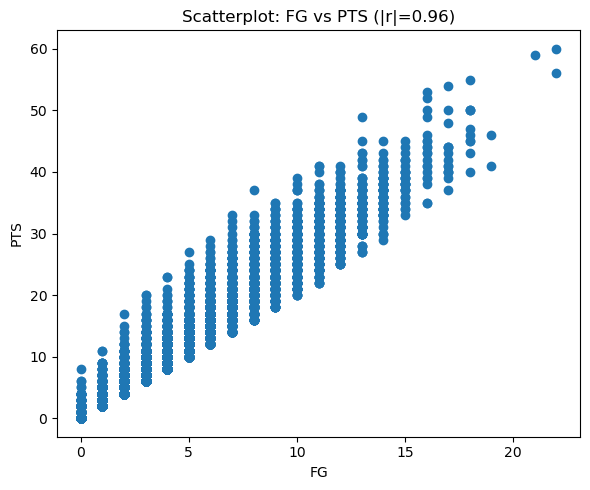

Interpretation: A tight linear pattern indicates redundancy.


In [24]:
if best_pair is not None:
    a, b = best_pair
    plt.figure(figsize=(6,5))
    plt.scatter(viz_df[a], viz_df[b])
    plt.title(f"Scatterplot: {a} vs {b} (|r|={best_pair_r:.2f})")
    plt.xlabel(a)
    plt.ylabel(b)
    plt.tight_layout()
    plt.show()

    print("Interpretation: A tight linear pattern indicates redundancy.")
else:
    print("No predictor pair scatterplot created because there were not enough numeric columns.")

# Project 5

In [25]:
df9 = viz_df.copy()

num_cols9 = df9.select_dtypes(include=np.number).columns.tolist()
cat_cols9 = df9.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", num_cols9[:10], "..." if len(num_cols9)>10 else "")
print("Categorical/object columns:", cat_cols9[:10], "..." if len(cat_cols9)>10 else "")

# 1) Grouping Data (Split-Apply-Combine)
group_cols = [TARGET_COL]
agg_features = [best_feature] + [c for c in top_features[1:3] if c in num_cols9]
agg_features = [c for c in agg_features if c in num_cols9]

if len(agg_features) == 0:
    print("No numeric features available for group statistics.")
else:
    grouped_stats = df9.groupby(TARGET_COL)[agg_features].agg(["mean", "std", "count"])
    print("\nGrouped summary by outcome (mean/std/count):")
    display(grouped_stats)

# 2) Applying Functions to Grouped Data
if best_feature in df9.columns:
    top_by_class = (
        df9.sort_values(best_feature, ascending=False)
           .groupby(TARGET_COL, as_index=False)
           .head(3)
    )
    print(f"\nTop 3 rows within each {TARGET_COL} group by {best_feature}:")
    display(top_by_class[[TARGET_COL, best_feature] + ([c for c in cat_cols9[:2] if c in df9.columns])].head(10))
else:
    print("Skipping top-N within groups because best_feature not found.")

# 3) Pivot Tables (only if categorical exists)
other_cats = [c for c in cat_cols9 if c != TARGET_COL]
if len(other_cats) == 0:
    print("\nPivot Table: Not applicable — no categorical columns besides the outcome were found in this dataset.")
else:
    pivot_cat = other_cats[0]
    if len(agg_features) == 0:
        print("\nPivot Table: Not applicable — no numeric measure found for values.")
    else:
        pivot_val = agg_features[0]
        pivot = df9.pivot_table(index=pivot_cat, columns=TARGET_COL, values=pivot_val, aggfunc="mean")
        print(f"\nPivot Table: mean({pivot_val}) by {pivot_cat} and {TARGET_COL}:")
        display(pivot)

# 4) Cross-Tabulation (frequency table)
if len(other_cats) == 0:
    print("\nCrosstab: Not applicable — no categorical columns besides the outcome were found in this dataset.")
else:
    ct_cat = other_cats[0]
    ctab = pd.crosstab(df9[ct_cat], df9[TARGET_COL], margins=True)
    print(f"\nCrosstab: {ct_cat} x {TARGET_COL} (counts):")
    display(ctab)

   
    pos_label = vals[1] if len(vals)==2 else labels[-1]
    if pos_label in ctab.columns and "All" in ctab.columns:
        rate = (ctab[pos_label] / ctab["All"]).drop("All", errors="ignore")
        rate_df = rate.reset_index()
        rate_df.columns = [ct_cat, "positive_rate"]
        print(f"\nWithin-category positive rate (P({TARGET_COL}={pos_label} | {ct_cat})):")
        display(rate_df)


Numeric columns: ['MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%'] ...
Categorical/object columns: ['Player', 'Tm', 'Opp', 'Res', 'Data'] 

Grouped summary by outcome (mean/std/count):


GmSc                       FG%                       3P%            \
          mean       std count      mean       std count      mean       std   
Res                                                                            
L     8.848414  7.088593  6934  0.434324  0.210372  6934  0.268571  0.267695   
W    11.290709  8.038383  6856  0.486582  0.208895  6856  0.321143  0.285237   

           
    count  
Res        
L    6934  
W    6856


Top 3 rows within each Res group by GmSc:


,Res,GmSc,Player,Tm
3619,W,54.2,Giannis Antetokounmpo,MIL
8125,W,48.7,Luka Dončić,DAL
3864,L,47.0,De'Aaron Fox,SAC
3337,W,46.5,Shai Gilgeous-Alexander,OKC
8279,L,44.5,Jimmy Butler,MIA
7368,L,43.8,Nikola Jokić,DEN



Pivot Table: mean(GmSc) by Player and Res:


Res,L,W
Player,,
A.J. Green,5.582353,5.816667
AJ Johnson,9.200000,NaN
Aaron Gordon,10.360000,11.368421
Aaron Holiday,2.288889,5.380000
Aaron Nesmith,4.466667,7.787500
...,...,...
Zach Edey,9.253846,10.086957
Zach LaVine,16.203846,18.700000
Zeke Nnaji,NaN,4.925000



Crosstab: Player x Res (counts):


Res,L,W,All
Player,,,
A.J. Green,17,24,41
AJ Johnson,1,0,1
Aaron Gordon,10,19,29
Aaron Holiday,9,10,19
Aaron Nesmith,6,8,14
...,...,...,...
Zach LaVine,26,18,44
Zeke Nnaji,0,4,4
Ziaire Williams,23,15,38



Within-category positive rate (P(Res=L | Player)):


,Player,positive_rate
0,A.J. Green,0.414634
1,AJ Johnson,1.000000
2,Aaron Gordon,0.344828
3,Aaron Holiday,0.473684
4,Aaron Nesmith,0.428571
...,...,...
505,Zach Edey,0.361111
506,Zach LaVine,0.590909
507,Zeke Nnaji,0.000000
508,Ziaire Williams,0.605263


# Project 6

ANOVA results: F-statistic = 8.836956521739141, p-value = 0.01627959539428573


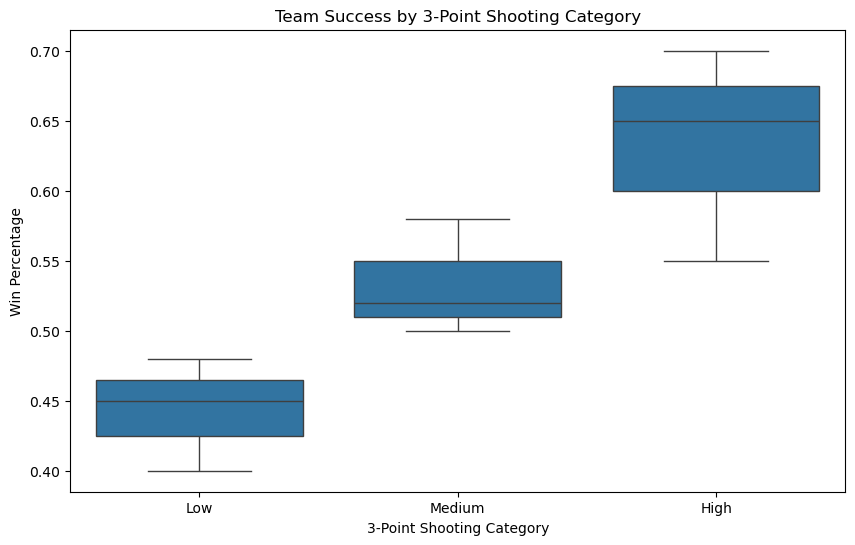

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

nba_data = pd.DataFrame({
    'team': ['Team A', 'Team B', 'Team C', 'Team D', 'Team E', 'Team F', 'Team G', 'Team H', 'Team I'],
    'three_pt_percentage': [0.32, 0.36, 0.40, 0.33, 0.38, 0.35, 0.42, 0.31, 0.37],
    'win_percentage': [0.45, 0.52, 0.65, 0.48, 0.55, 0.50, 0.70, 0.40, 0.58]
})

nba_data['three_pt_category'] = pd.qcut(nba_data['three_pt_percentage'], 3, 
                                       labels=['Low', 'Medium', 'High'])

low_group = nba_data[nba_data['three_pt_category'] == 'Low']['win_percentage']
medium_group = nba_data[nba_data['three_pt_category'] == 'Medium']['win_percentage']
high_group = nba_data[nba_data['three_pt_category'] == 'High']['win_percentage']

f_stat, p_value = stats.f_oneway(low_group, medium_group, high_group)
print(f"ANOVA results: F-statistic = {f_stat}, p-value = {p_value}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='three_pt_category', y='win_percentage', data=nba_data)
plt.title('Team Success by 3-Point Shooting Category')
plt.xlabel('3-Point Shooting Category')
plt.ylabel('Win Percentage')
plt.show()

In [31]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             target_win   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     22.35
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.23e-37
Time:                        00:02:42   Log-Likelihood:                -3451.5
No. Observations:                4892   AIC:                             6923.
Df Residuals:                    4882   BIC:                             6988.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5331      0.075      7.070      0.000       0.385       0.681
3p             0.0561      0.006      8.933      0.000       0.044       0.068
3pa           -0.0260      0.003     -7.679      0.000      -0.033      -0.019
orb           -0.0002      0.005     -0.040      0.968      -0.009       0.009
ast            0.0195      0.002      7.933      0.000       0.015       0.024
stl            0.0223      0.006      3.649      0.000       0.010       0.034
blk            0.0361      0.007      5.089      0.000       0.022       0.050
tov           -0.0221      0.004     -5.003      0.000      -0.031      -0.013
pf            -0.0203      0.005     -4.013      0.000      -0.030      -0.010
mp            -0.0012      0.002     -0.521      0.602      -0.006       0.003
==============================================================================
Omnibus:                    18833.681   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              693.871
Skew:                          -0.019   Prob(JB):                    2.13e-151
Kurtosis:                       1.155   Cond. No.                         388.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

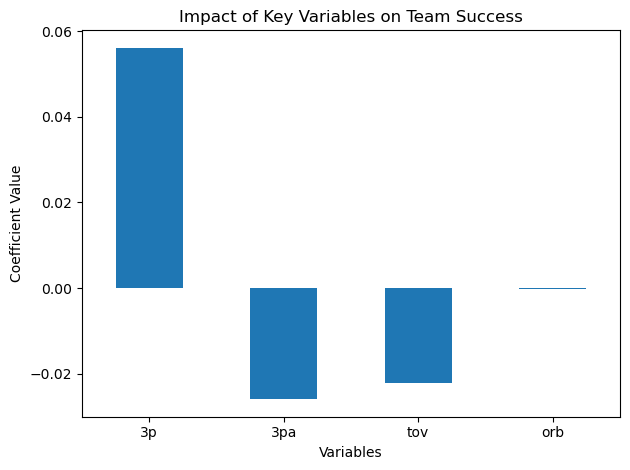

In [33]:
coefficients = model.params[['3p', '3pa', 'tov', 'orb']]

coefficients.plot(kind='bar')

plt.title("Impact of Key Variables on Team Success")
plt.ylabel("Coefficient Value")
plt.xlabel("Variables")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [35]:
results = pd.DataFrame({
    "Coefficient": model.params[['3p','3pa','tov','orb']],
    "P-value": model.pvalues[['3p','3pa','tov','orb']]
})
results

,Coefficient,P-value
3p,0.056066,5.750138e-19
3pa,-0.025951,1.921189e-14
tov,-0.022112,5.831720e-07
orb,-0.000190,9.679017e-01


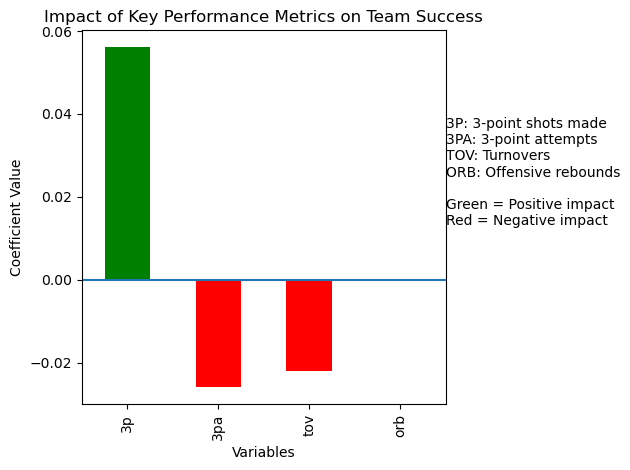

In [47]:
vars = ['3p', '3pa', 'tov', 'orb']

coefs = model.params[vars]

coefs.plot(kind='bar')

plt.title("Impact of Key Performance Metrics on Team Success")
plt.ylabel("Coefficient Value")
plt.xlabel("Variables")
plt.xticks(rotation=0)

colors = ['green' if x > 0 else 'red' for x in coefs]

coefs.plot(kind='bar', color=colors)

plt.axhline(0)

text = (
    "3P: 3-point shots made\n"
    "3PA: 3-point attempts\n"
    "TOV: Turnovers\n"
    "ORB: Offensive rebounds\n\n"
    "Green = Positive impact\n"
    "Red = Negative impact"
)

plt.text(3.5, max(coefs)*0.7, text, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()